In [24]:
from pathlib import Path
from helpers import get_poi_upper_limit,get_signal_yieldsFrom,to_cut_name,get_model_pars
from spey import ExpectationType
import warnings
warnings.filterwarnings("ignore", message="numpy.dtype size changed")
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.lines import Line2D
pd.option_context('display.max_columns', -1)

pd.options.mode.chained_assignment = None #Disable copy warnings
# plt.style.use('fivethirtyeight') #Set style
# mpl.rcParams.update({'figure.figsize' : (15,10)})  #Set general plotting options
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})

plt.rcParams.update({"savefig.dpi" : 300}) #Figure resolution


#Define plotting style:
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=1.8)
cm = plt.colormaps['RdYlBu']


## Get Recasting Results

In [2]:
results_dir = Path('./HeHe_results/HeHe_ee')
slha_dir = Path('./slhaFiles')
usePickleFile = 'HeHe_results.pcl'
usePickleFile = True

In [3]:
if usePickleFile and Path(usePickleFile).exists():
    resultsDF = pd.read_pickle(usePickleFile)
else:
    resultsDict = {}
    for signal_file in results_dir.rglob('*signal.dat'):
        srDict = get_signal_yieldsFrom(Path(signal_file))
        slhaFile = Path(signal_file).parent.parent.name+ '.dat'
        slhaFile = Path(slha_dir, slhaFile)
        modelPars = get_model_pars(slhaFile)
        if modelPars in resultsDict:
            for key,val in srDict.items():
                resultsDict[modelPars][key] += val
        else:
            resultsDict[modelPars] = srDict
    resultsDF = pd.DataFrame.from_dict(resultsDict, orient='index')
    resultsDF.reset_index(inplace=True)
    resultsDF.rename(columns={'index':'modelPars', 'level_0' : 'M1', 'level_1' : 'M0'}, inplace=True)
    resultsDF.sort_values(by=['M1', 'M0'], inplace=True)
    resultsDF['muUL_observed'] = np.nan

SRcols = [col for col in resultsDF.columns if 'SR' in col]

### Compute combined upper limit

In [4]:
def compute_poi_ul(row, expected=ExpectationType.observed,replace=False):
    signal_yields = row[SRcols].fillna(0.0).to_dict()
    muUL = row['muUL_observed']
    if np.isnan(muUL) or replace:
        return get_poi_upper_limit(signal_yields=signal_yields, expected=expected)
    else:
        return muUL

resultsDF['muUL_observed'] = resultsDF.apply(compute_poi_ul, axis=1)
resultsDF.to_pickle('HeHe_results.pcl')

### Plot results

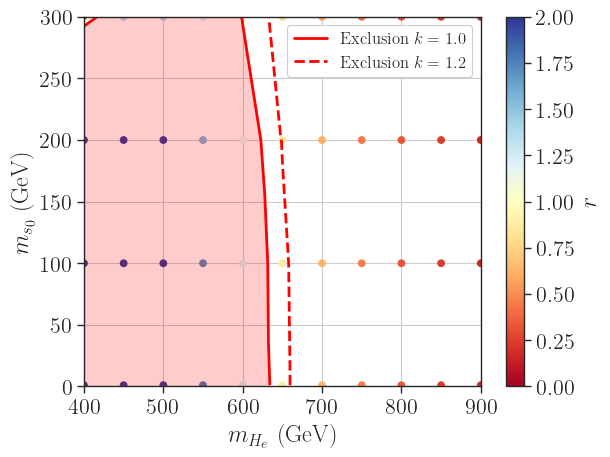

In [32]:
z = 1.0 / resultsDF["muUL_observed"]

plt.scatter(resultsDF['M1'], resultsDF['M0'], 
          c=z, 
          marker='o', cmap=cm, vmin=0., vmax=2.0)
plt.colorbar(label=r'$r$')

# Shade the region above the first contour (r >= 1.0).
zmax = max(float(np.nanmax(z)), 1.0 + 1e-6)
plt.tricontourf(
    resultsDF["M1"], resultsDF["M0"],
    z,
    levels=[1.0, zmax], colors=["red"], alpha=0.20
)

plt.tricontour(
    resultsDF["M1"], resultsDF["M0"],
    z,
    levels=[1.0], colors="red", linewidths=2
)
plt.tricontour(
    resultsDF["M1"], resultsDF["M0"],
    z,
    levels=[1.0/1.2], colors="red", linewidths=2,linestyles='dashed'
)

proxy = Line2D([], [], color="red", lw=2, label=r"Exclusion $k = 1.0$")
proxy2 = Line2D([], [], color="red", lw=2, label=r"Exclusion $k = 1.2$", linestyle='dashed')
plt.legend(handles=[proxy, proxy2],fontsize=12, loc='upper right',framealpha=1.0)
plt.xlabel(r'$m_{H_e}$ (GeV)')
plt.ylabel(r'$m_{s_0}$ (GeV)')
plt.xlim(400, 900)
plt.ylim(0, 300)
plt.grid()
plt.savefig('HeHe_exclusion.pdf', bbox_inches='tight')
plt.show()

In [10]:
results_bench = resultsDF[(resultsDF['M1'] == 400) & (resultsDF['M0'] == 200)]
results_bench.iloc[0].T

M1                  400.000000
M0                  200.000000
xsec_fb               2.160465
mcevents         100000.000000
SRDF_0a_cuts          0.474489
SRDF_0b_cuts          0.525541
SRDF_0c_cuts          1.063095
SRDF_0d_cuts          2.177240
SRDF_0e_cuts          2.327400
SRDF_0f_cuts          2.585670
SRDF_0g_cuts          4.874020
SRDF_0h_cuts          4.693830
SRDF_0i_cuts          8.555820
SRDF_1a_cuts          0.258267
SRDF_1b_cuts          0.258266
SRDF_1c_cuts          0.744767
SRDF_1d_cuts          1.351391
SRDF_1e_cuts          1.312351
SRDF_1f_cuts          1.438481
SRDF_1g_cuts          3.060150
SRDF_1h_cuts          2.849930
SRDF_1i_cuts          5.210370
SRSF_0a_cuts          0.336337
SRSF_0b_cuts          0.441441
SRSF_0c_cuts          0.969969
SRSF_0d_cuts          2.159153
SRSF_0e_cuts          2.387381
SRSF_0f_cuts          2.360354
SRSF_0g_cuts          4.699690
SRSF_0h_cuts          4.141130
SRSF_0i_cuts          6.846920
SRSF_1a_cuts          0.237237
SRSF_1b_

In [16]:
signal_yields = results_bench.iloc[0][SRcols].fillna(0.0).to_dict()
muUL_tot = get_poi_upper_limit(signal_yields=signal_yields, expected=ExpectationType.observed)
print(f"Total muUL for benchmark point: {muUL_tot:.2f} (Lucas = {0.343:.3f})")

Total muUL for benchmark point: 0.29 (Lucas = 0.343)


In [17]:
signal_yields_SF = {sr : 0.0 for sr in signal_yields.items()}
signal_yields_SF.update({sr : value for sr, value in signal_yields.items() if 'SF' in sr})

muUL_SF = get_poi_upper_limit(signal_yields=signal_yields_SF, expected=ExpectationType.observed)
print(f"SF muUL for benchmark point: {muUL_SF:.2f} (Lucas = {0.534:.3f})")

SF muUL for benchmark point: 0.47 (Lucas = 0.534)


In [18]:
signal_yields_DF = {sr : 0.0 for sr in signal_yields.items()}
signal_yields_DF.update({sr : value for sr, value in signal_yields.items() if 'DF' in sr})

muUL_DF = get_poi_upper_limit(signal_yields=signal_yields_DF, expected=ExpectationType.observed)
print(f"DF muUL for benchmark point: {muUL_DF:.2f} (Lucas = {0.446:.3f})")

DF muUL for benchmark point: 0.37 (Lucas = 0.446)


In [ ]:
#0.534(SF),0.446(DF)->0.343